<a href="https://colab.research.google.com/github/MaAlejandraM/Parcial_2_programacion_ciencia_datos/blob/main/probando_ev_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial N°2

## Integrantes:

*   Maria Alejandra Marambio
*   Pamela Toro

### Fecha: Martes 19 de mayo, 2026.-

##Contexto
En el ámbito de la seguridad espacial y la astrofísica, el monitoreo de los Objetos Cercanos a la Tierra (NEO), como los asteroides, es una tarea crítica para la NASA y la comunidad científica internacional. Debido al volumen masivo de datos recopilados diariamente por los telescopios automáticos, se vuelve fundamental el uso de técnicas avanzadas de Ciencia de Datos y Machine Learning para optimizar la identificación de amenazas potenciales sin depender exclusivamente de la revisión manual humana.

# 1. Importar las librerías a utilizar

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y evaluación
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Configuración de reproducibilidad (Seed)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 2. Cargar los datos en un dataframe original y en el dataframe a utilizar.

In [ ]:
df_original = pd.read_csv('neo.csv')
df = df_original.copy()

# 3. Preparación y análisis exploratorio de datos.

In [ ]:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [ ]:
#revisamos la cantidad de filas y columnas
df.shape

(90836, 10)

In [ ]:
# Permite generar un resumen estadístico de las columnas numéricas y transponerlo para que las métricas aparezcan como columnas, facilitando la lectura cuando hay muchas variables.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,90836.0,1.438288e+07,2.087202e+07,2.000433e+06,3.448110e+06,3.748362e+06,3.884023e+06,5.427591e+07
est_diameter_min,90836.0,1.274321e-01,2.985112e-01,6.089126e-04,1.925551e-02,4.836765e-02,1.434019e-01,3.789265e+01
est_diameter_max,90836.0,2.849469e-01,6.674914e-01,1.361570e-03,4.305662e-02,1.081534e-01,3.206564e-01,8.473054e+01
relative_velocity,90836.0,4.806692e+04,2.529330e+04,2.033464e+02,2.861902e+04,4.419012e+04,6.292360e+04,2.369901e+05
miss_distance,90836.0,3.706655e+07,2.235204e+07,6.745533e+03,1.721082e+07,3.784658e+07,5.654900e+07,7.479865e+07
absolute_magnitude,90836.0,2.352710e+01,2.894086e+00,9.230000e+00,2.134000e+01,2.370000e+01,2.570000e+01,3.320000e+01


In [ ]:
# Permite generar un resumen estadístico de las columnas numéricas y transponerlo para que las métricas aparezcan como columnas, facilitando la lectura cuando hay muchas variables.
df.describe(include='O').T

,count,unique,top,freq
name,90836,27423,277810 (2006 FV35),43
orbiting_body,90836,1,Earth,90836


In [ ]:
#nos permite ver los nombres de las columnas
df.columns

Index(['id', 'name', 'est_diameter_min', 'est_diameter_max',
       'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object',
       'absolute_magnitude', 'hazardous'],
      dtype='object')

In [ ]:
# Permite obtener un resumen rápido de la estructura del DataFrame, mostrando el número de filas, columnas, tipos de datos y el uso de memoria.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


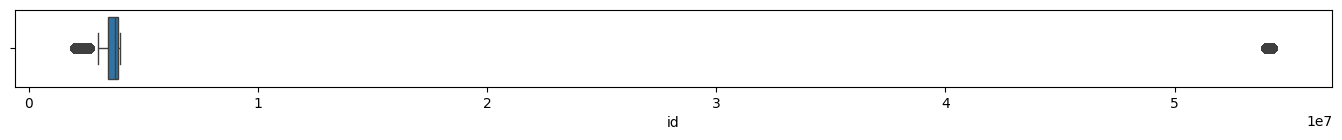

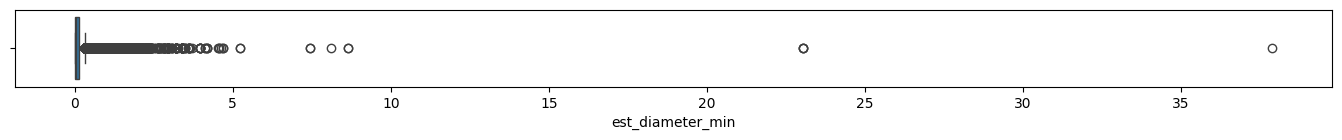

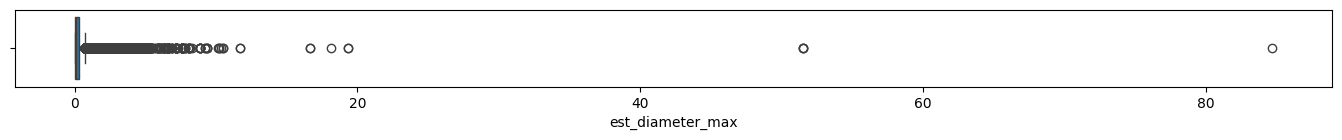

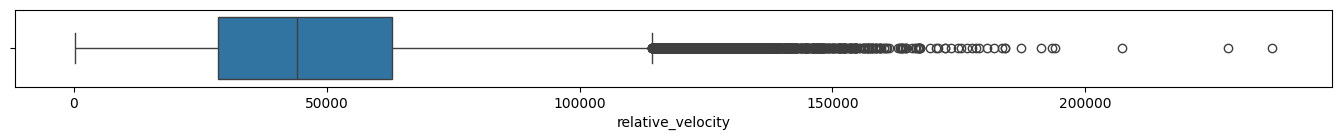

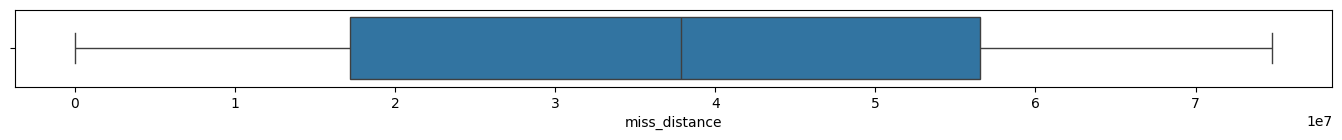

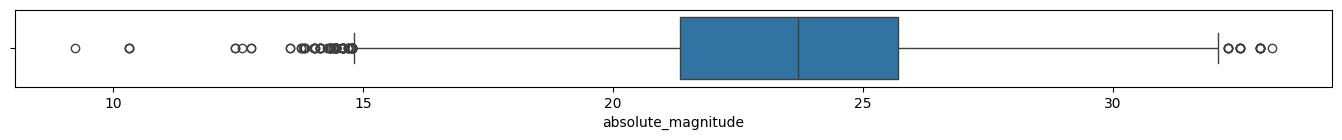

In [ ]:
# Con este grafico de cajas verificamos los outliers para variables numericas
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
  plt.figure(figsize=(17,1))
  sns.boxplot(data=df[num_cols], x=col)

In [ ]:
# Permite identificar y contar la cantidad total de valores nulos o faltantes que existen en cada una de las columnas del DataFrame.
print("Valores nulos por columnas")
print(df.isnull().sum())

Valores nulos por columnas
id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64


In [ ]:
# Datos duplicados:
df.duplicated().sum()

np.int64(0)

/tmp/ipykernel_3808/978598509.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis', ax=axes[i])
/tmp/ipykernel_3808/978598509.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis', ax=axes[i])
/tmp/ipykernel_3808/978598509.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis', ax=axes[i])


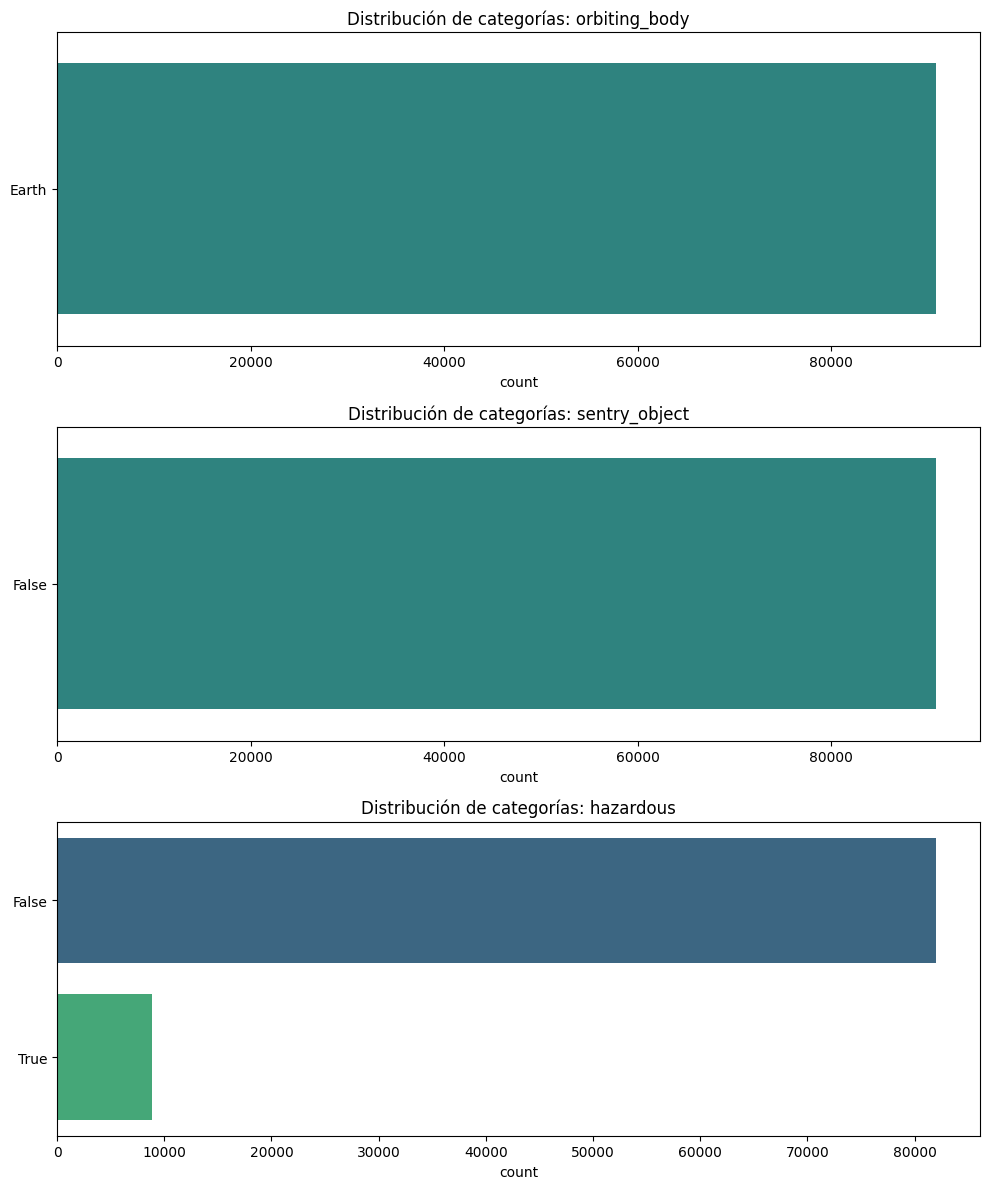

In [ ]:
#Grafico para visualizar las variables categoricas
categoricas = ['orbiting_body', 'sentry_object', 'hazardous']

# Create a single figure with subplots arranged vertically
fig, axes = plt.subplots(nrows=len(categoricas), ncols=1, figsize=(10, 4 * len(categoricas)))

# Ensure axes is an array even if there's only one subplot
if len(categoricas) == 1:
    axes = [axes]

for i, col in enumerate(categoricas):
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Distribución de categorías: {col}')
    axes[i].set_ylabel('') # Remove y-axis label to avoid redundancy

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

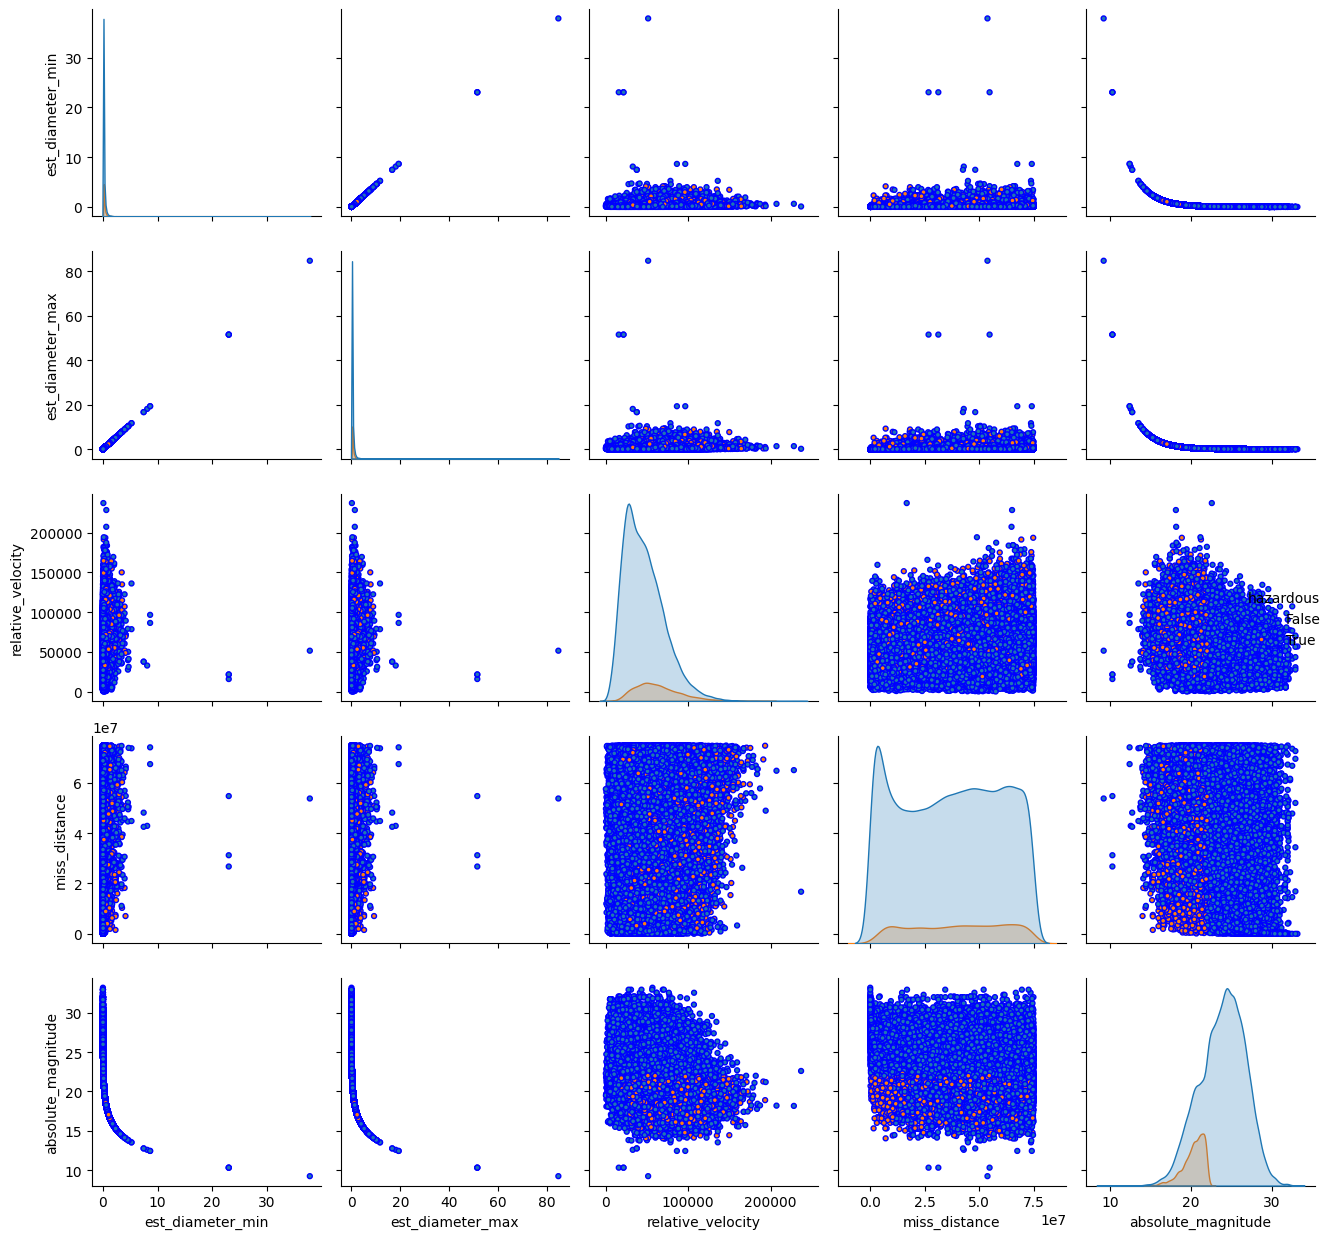

In [ ]:
sns.pairplot(data=df,
             diag_kind="kde",
             markers=".",
             plot_kws=dict(s=50, edgecolor="b", linewidth=1),
             hue="hazardous",
             vars=["est_diameter_min",
                   "est_diameter_max",
                   "relative_velocity",
                   "miss_distance",
                   "absolute_magnitude"])

plt.tight_layout()
plt.show()

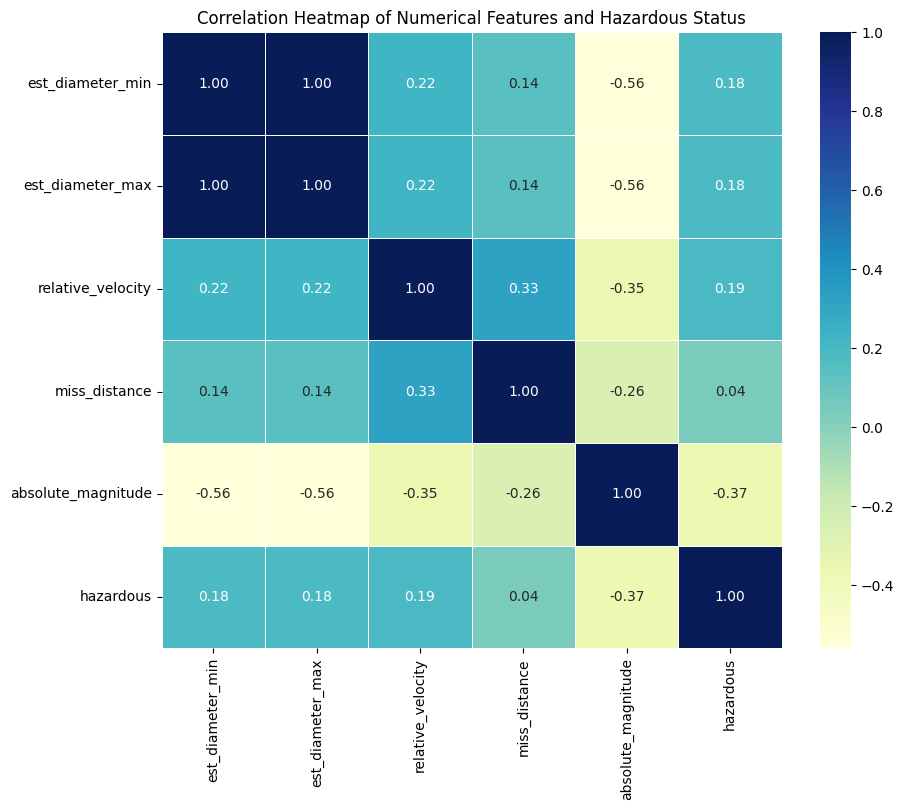

In [ ]:
df_for_corr = df.copy()

df_for_corr.dropna(subset=['hazardous', 'absolute_magnitude'], inplace=True)

df_for_corr['hazardous'] = df_for_corr['hazardous'].astype(int)

numerical_and_target_cols = [
    'est_diameter_min', 'est_diameter_max', 'relative_velocity',
    'miss_distance', 'absolute_magnitude', 'hazardous'
]

correlation_matrix = df_for_corr[numerical_and_target_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="YlGnBu", linewidths=.5, annot=True, fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features and Hazardous Status')
plt.show()

##Distribucion de la variable objetivo

In [ ]:
print(df['hazardous'].value_counts())

hazardous
False    81996
True      8840
Name: count, dtype: int64


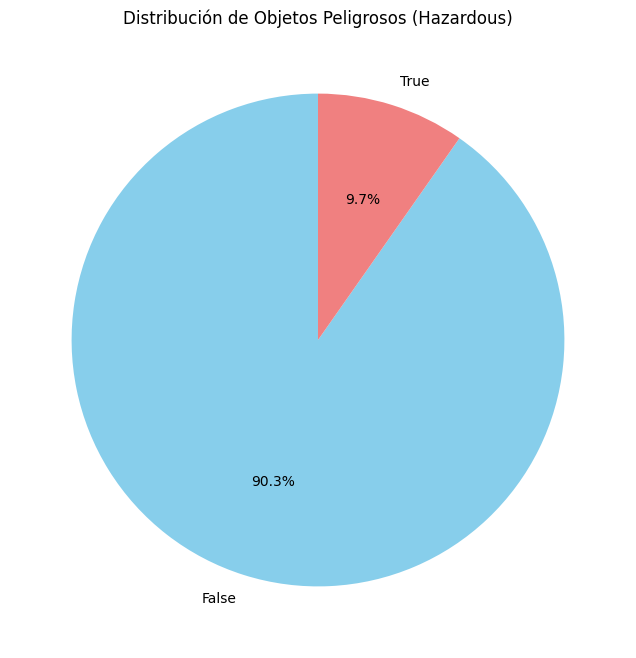

In [ ]:
hazardous_counts = df['hazardous'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(hazardous_counts, labels=hazardous_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribución de Objetos Peligrosos (Hazardous)')
plt.show()

##Estandarización de las variables numéricas y Codificación por LabelEncoder a la variable Hazardous


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Reinicializa df desde df_original para asegurarte de que todas las columnas estén presentes.
df = df_original.copy()

# Aplicar LabelEncoder a la columna 'hazardous'
#Esto garantiza que la palabra 'hazardous' se codifique antes de que se escalen las demás columnas numéricas.
le = LabelEncoder()
df['hazardous'] = le.fit_transform(df['hazardous'])

# Identificar las columnas numéricas a estandarizar
# Excluyendo 'id' que es un identificador y 'hazardous' que es la variable objetivo binaria
numerical_cols_to_scale = ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

# Inicializar el StandardScaler
scaler = StandardScaler()

# Aplicar la estandarización a las columnas seleccionadas
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

print("DataFrame después de estandarizar las columnas numéricas:")
display(df.head())

DataFrame después de estandarizar las columnas numéricas:


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),3.587284,3.587284,-1.363913,0.795153,Earth,False,-2.348632,0
1,2277475,277475 (2005 WK4),0.463529,0.463529,1.009040,1.090357,Earth,False,-1.218735,1
2,2512244,512244 (2015 YE18),1.991887,1.991887,2.616983,0.569624,Earth,False,-1.968544,0
3,3596030,(2012 BV13),-0.103601,-0.103601,-0.921301,-0.520384,Earth,False,-0.458560,0
4,3667127,(2014 GE35),0.427378,0.427378,-0.210697,0.412001,Earth,False,-1.187637,1


Optamos por aplicar Estandarización (StandardScaler) en lugar de Normalización debido al comportamiento astronómico de nuestros datos. El dataset de la NASA presenta una alta presencia de valores atípicos u outliers, especialmente en los diámetros estimados y en las distancias de aproximación.

Si hubiésemos aplicado una normalización MinMaxScaler, habríamos corrido el riesgo de comprimir y ocultar la variabilidad del 99% de los asteroides por culpa de unos pocos cuerpos celestes gigantescos. Además, nuestros algoritmos no supervisados PCA y K-Means asumen de forma nativa que los datos están centrados en cero con varianza unitaria. Por lo tanto, la estandarización es la única técnica que garantiza la estabilidad matemática de todo nuestro pipeline, evitando que las amenazas extremas distorsionen el entrenamiento del modelo.

AGREGAR LO DE LABELENCODER!!!!

# Eliminación de columnas del dataframe

In [ ]:
cols_to_drop = ['id','name', 'orbiting_body', 'sentry_object']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("DataFrame después de eliminar columnas:")
display(df.head())

DataFrame después de eliminar columnas:


,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,3.587284,3.587284,-1.363913,0.795153,-2.348632,0
1,0.463529,0.463529,1.009040,1.090357,-1.218735,1
2,1.991887,1.991887,2.616983,0.569624,-1.968544,0
3,-0.103601,-0.103601,-0.921301,-0.520384,-0.458560,0
4,0.427378,0.427378,-0.210697,0.412001,-1.187637,1


Se realizó un filtrado de características (Feature Selection) eliminando variables constantes y de identificación para reducir el ruido y mejorar la eficiencia computacional de los modelos supervisados.

# 4. Modelados supervisados (al menos un modelo)

## Modelo de Regresion logistica:

--- Ejecutando Validación Cruzada (5 Pliegues) ---
ACCURACY promedio en CV: 0.7840 (+/- 0.0018)
PRECISION promedio en CV: 0.3021 (+/- 0.0016)
RECALL promedio en CV: 0.9306 (+/- 0.0075)
F1 promedio en CV: 0.4561 (+/- 0.0021)
ROC_AUC promedio en CV: 0.8749 (+/- 0.0027)

--- INFORME DE CLASIFICACIÓN FINAL (TEST SET) ---
              precision    recall  f1-score   support

           0       0.99      0.77      0.87     16400
           1       0.30      0.93      0.46      1768

    accuracy                           0.79     18168
   macro avg       0.65      0.85      0.66     18168
weighted avg       0.92      0.79      0.83     18168



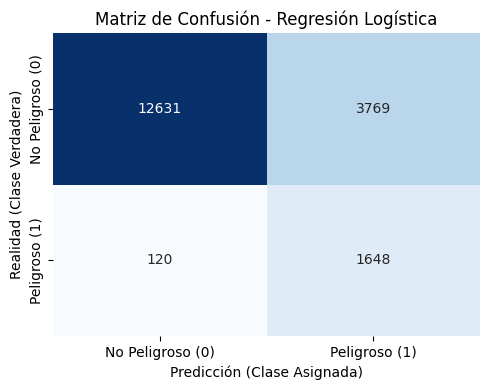

In [ ]:
# 1. Configuración de Reproducibilidad (Semilla global)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Filter out the row where 'hazardous' had a NaN (which is now encoded as a unique integer, e.g., 2).
# Based on previous outputs, 'hazardous' has one NaN which gets encoded by LabelEncoder, likely as '2'.
# This row needs to be removed before stratified splitting.
df_cleaned = df[df['hazardous'] != 2].copy()

# Separar características (X) y variable objetivo codificada (y)
# Use df_cleaned instead of df
X = df_cleaned.drop(columns=['id', 'name', 'orbiting_body', 'sentry_object', 'hazardous'], errors='ignore')
y = df_cleaned['hazardous'].astype(int)

# Separar en conjuntos de entrenamiento y prueba (Estratificado por el desbalance de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 2. Pipeline de Preprocesamiento Técnico
# Identificar columnas numéricas automáticamente
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Robustez ante nulos
    ('scaler', StandardScaler())                  # Vital para la convergencia de la Regresión Logística
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, num_features)]
)

# 3. Definición del Pipeline del Modelo (Regresión Logística)
# Nota: Usamos class_weight='balanced' para combatir el fuerte desbalance de asteroides peligrosos
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

# 4. Validación Cruzada Robusta
# Evaluamos usando múltiples métricas simultáneamente según la pauta
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("--- Ejecutando Validación Cruzada (5 Pliegues) ---")
cv_results = cross_validate(
    pipeline_lr, X_train, y_train, cv=5, scoring=scoring_metrics, return_train_score=False
)

# Mostrar resultados promedio de la Validación Cruzada
for metric in scoring_metrics:
    mean_score = cv_results[f'test_{metric}'].mean()
    std_score = cv_results[f'test_{metric}'].std()
    print(f"{metric.upper()} promedio en CV: {mean_score:.4f} (+/- {std_score:.4f})")

# 5. Entrenamiento Final y Evaluación con el Conjunto de Prueba (Test Set)
pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)
y_proba = pipeline_lr.predict_proba(X_test)[:, 1]

# Informe de Clasificación Técnico
print("\n--- INFORME DE CLASIFICACIÓN FINAL (TEST SET) ---")
print(classification_report(y_test, y_pred))

# 6. Visualización Clave: Matriz de Confusión
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción (Clase Asignada)')
plt.ylabel('Realidad (Clase Verdadera)')
plt.xticks([0.5, 1.5], ['No Peligroso (0)', 'Peligroso (1)'])
plt.yticks([0.5, 1.5], ['No Peligroso (0)', 'Peligroso (1)'])
plt.tight_layout()
plt.show()

"Elegimos Regresión Logística principalmente como nuestro modelo de línea base (baseline) debido a su alta interpretabilidad y eficiencia computacional. Al ser un problema de clasificación binaria (determinar si un asteroide es peligroso o no), nos otorgó un punto de partida matemático claro mediante coeficientes directos. Además, al integrar la configuración de pesos balanceados, nos permitió mitigar el fuerte desbalance del dataset de la NASA y establecer una comparación rigurosa contra el modelo no lineal."

## Modelo Árbol de decisión

--- Ejecutando Validación Cruzada (5 Pliegues) ---
ACCURACY promedio en CV: 0.8937 (+/- 0.0017)
PRECISION promedio en CV: 0.4511 (+/- 0.0096)
RECALL promedio en CV: 0.4249 (+/- 0.0156)
F1 promedio en CV: 0.4375 (+/- 0.0119)
ROC_AUC promedio en CV: 0.6846 (+/- 0.0076)

--- INFORME DE CLASIFICACIÓN FINAL (TEST SET) ---
                  precision    recall  f1-score   support

No Peligroso (0)       0.94      0.94      0.94     16400
   Peligroso (1)       0.46      0.44      0.45      1768

        accuracy                           0.90     18168
       macro avg       0.70      0.69      0.70     18168
    weighted avg       0.89      0.90      0.89     18168



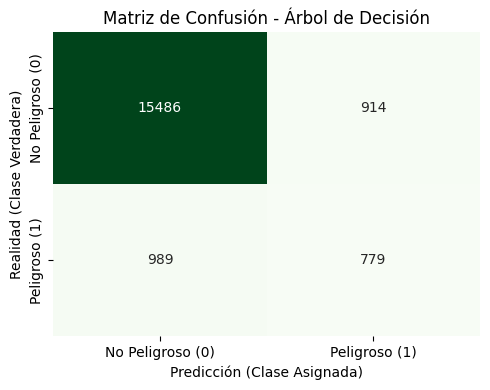

In [ ]:
# 1. Configuración de Reproducibilidad (Semilla global)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Crear un DataFrame temporal y limpiar filas con NaN en 'hazardous'
# Esto es crucial para que LabelEncoder no cree una clase de un solo miembro
# y para que train_test_split con stratify funcione correctamente.
df_temp_cleaned = df_original.dropna(subset=['hazardous']).copy()

# Separar características (X) y variable objetivo de df_temp_cleaned
X = df_temp_cleaned.drop(columns=['id', 'name', 'orbiting_body', 'sentry_object', 'hazardous'], errors='ignore')

# Asegurar codificación numérica de la variable objetivo (0 = No peligroso, 1 = Peligroso)
le = LabelEncoder()
y = le.fit_transform(df_temp_cleaned['hazardous'])

# Separar en conjuntos de entrenamiento y prueba (Estratificado por el desbalance de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 2. Pipeline de Preprocesamiento Técnico
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Robustez ante nulos
    ('scaler', StandardScaler())                  # Aunque el árbol no lo exige estrictamente, mantiene la homogeneidad del flujo
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, num_features)]
)

# 3. Definición del Pipeline del Modelo (Árbol de Decisión)
# Nota: Usamos class_weight='balanced' para ajustar la ganancia de información (Gini/Entropy)
# penalizando más los errores en la clase minoritaria (asteroides peligrosos)
pipeline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

# 4. Validación Cruzada Robusta (5 Pliegues)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("--- Ejecutando Validación Cruzada (5 Pliegues) ---")
cv_results_dt = cross_validate(
    pipeline_dt, X_train, y_train, cv=5, scoring=scoring_metrics, return_train_score=False
)

# Mostrar resultados promedio de la Validación Cruzada
for metric in scoring_metrics:
    mean_score = cv_results_dt[f'test_{metric}'].mean()
    std_score = cv_results_dt[f'test_{metric}'].std()
    print(f"{metric.upper()} promedio en CV: {mean_score:.4f} (+/- {std_score:.4f})")

# 5. Entrenamiento Final y Evaluación con el Conjunto de Prueba (Test Set)
pipeline_dt.fit(X_train, y_train)
y_pred_dt = pipeline_dt.predict(X_test)
y_proba_dt = pipeline_dt.predict_proba(X_test)[:, 1]

# Informe de Clasificación Técnico
print("\n--- INFORME DE CLASIFICACIÓN FINAL (TEST SET) ---")
print(classification_report(y_test, y_pred_dt, target_names=['No Peligroso (0)', 'Peligroso (1)']))

# 6. Visualización Clave: Matriz de Confusión
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens', cbar=False) # Usamos Greens para diferenciarlo de la Regresión Logística
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicción (Clase Asignada)')
plt.ylabel('Realidad (Clase Verdadera)')
plt.xticks([0.5, 1.5], ['No Peligroso (0)', 'Peligroso (1)'])
plt.yticks([0.5, 1.5], ['No Peligroso (0)', 'Peligroso (1)'])
plt.tight_layout()
plt.show()

Utilizamos este modelo porque nos otorga un alto nivel de explicabilidad científica. El árbol nos permite mapear visualmente la lógica del modelo mediante bifurcaciones basadas en umbrales físicos reales (como el diámetro crítico o la velocidad límite). Al ser un modelo no paramétrico, no requiere que los datos sean lineales ni se ve afectado por los valores atípicos extremos del dataset, permitiéndonos contrastar su rendimiento contra la Regresión Logística.

# 5. Modelado no supervisado (al menos un método de clustering o reducción de dimensionalidad)

##Modelo PCA (reduccion de dimensionalidad)

In [ ]:
numerical_cols_to_scale = ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']
# Creamos un dataset exclusivo para la etapa No Supervisada
X_nobasado = df_original[numerical_cols_to_scale]

# Es obligatorio escalar antes de PCA/KMeans
X_ns_scaled = scaler.fit_transform(X_nobasado)

--- ANÁLISIS DE PCA (SOBRE EL CONJUNTO DE ENTRENAMIENTO) ---
Varianza explicada por la Componente 1: 52.54%
Varianza explicada por la Componente 2: 23.86%
Varianza total acumulada por ambas componentes: 76.40%

--- CONTRIBUCIÓN DE LAS VARIABLES ORIGINALES A LAS COMPONENTES (LOADINGS) ---


,PC1,PC2
est_diameter_min,0.561751,-0.333052
est_diameter_max,0.561751,-0.333052
relative_velocity,0.296675,0.580082
miss_distance,0.232606,0.656426
absolute_magnitude,-0.476184,-0.103742


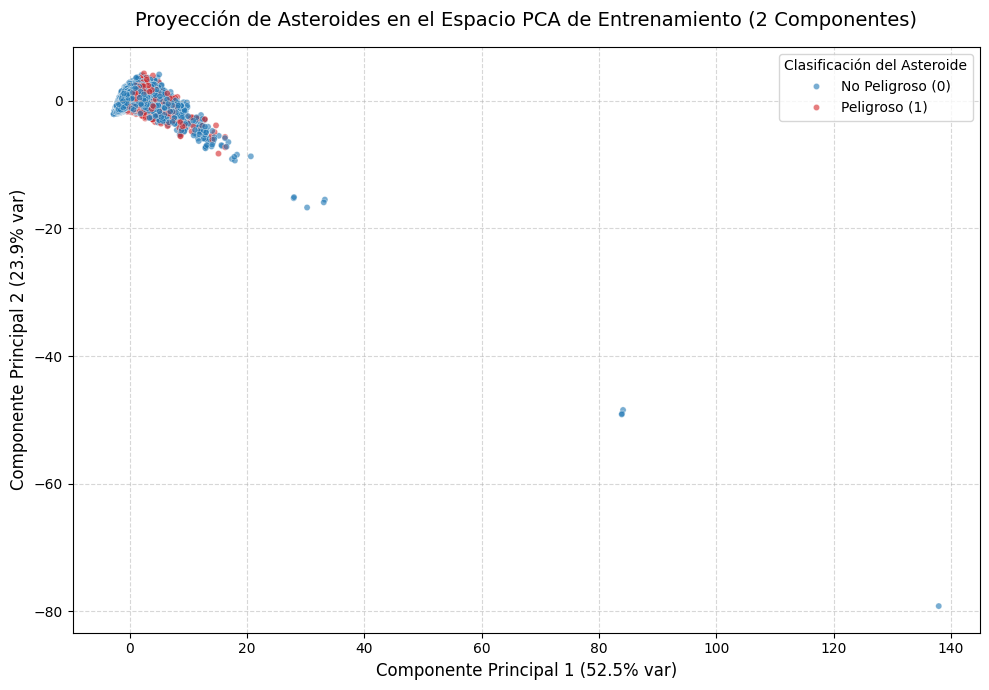

In [ ]:
# 1. Configuración de Reproducibilidad (Semilla global)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- CORRECCIÓN CRÍTICA DE FLUJO ---
# Volvemos a leer de df_original por consistencia metodológica.
# Usamos las mismas particiones de Train y Test que los modelos supervisados.
X = df_original.drop(columns=['id', 'name', 'orbiting_body', 'sentry_object', 'hazardous'], errors='ignore')

le = LabelEncoder()
y = le.fit_transform(df_original['hazardous'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# 2. Pipeline de Preprocesamiento (Obligatorio para PCA)
# PCA calcula direcciones de máxima varianza; si no escalamos, la variable con
# magnitudes más grandes (ej. miss_distance) dominará artificialmente el análisis.
num_features = X.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, num_features)]
)

# Ajustamos el preprocesador SOLO con Train y transformamos ambos conjuntos
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# 3. Implementation de PCA (Ajustado estrictamente con X_train_scaled)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled) # Se mapea Test al espacio descubierto en Train

# Creamos un DataFrame con los componentes del set de entrenamiento para la visualización
df_train_pca = pd.DataFrame(data=X_train_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
df_train_pca['hazardous'] = y_train

# 4. Análisis de Varianza Explicada
varianza_explicada = pca.explained_variance_ratio_

print("--- ANÁLISIS DE PCA (SOBRE EL CONJUNTO DE ENTRENAMIENTO) ---")
print(f"Varianza explicada por la Componente 1: {varianza_explicada[0]*100:.2f}%")
print(f"Varianza explicada por la Componente 2: {varianza_explicada[1]*100:.2f}%")
print(f"Varianza total acumulada por ambas componentes: {np.sum(varianza_explicada)*100:.2f}%\n")

# Extra: Inspección de los Pesos (Loadings) para la Defensa Teórica
print("--- CONTRIBUCIÓN DE LAS VARIABLES ORIGINALES A LAS COMPONENTES (LOADINGS) ---")
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=num_features)
display(loadings)

# Clonamos el dataframe y formateamos las etiquetas para la leyenda
df_train_pca_plot = df_train_pca.copy()
df_train_pca_plot['¿Es Peligroso?'] = df_train_pca_plot['hazardous'].map({0: 'No Peligroso (0)', 1: 'Peligroso (1)'})

# Configuración del tamaño de la figura (Recomendado para Colab)
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x='Componente Principal 1',
    y='Componente Principal 2',
    hue='¿Es Peligroso?',
    data=df_train_pca_plot,
    palette={'No Peligroso (0)': '#1f77b4', 'Peligroso (1)': '#d62728'},
    alpha=0.6,
    s=20
)

plt.title('Proyección de Asteroides en el Espacio PCA de Entrenamiento (2 Componentes)', fontsize=14, pad=15)
plt.xlabel(f'Componente Principal 1 ({varianza_explicada[0]*100:.1f}% var)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({varianza_explicada[1]*100:.1f}% var)', fontsize=12)

plt.legend(title='Clasificación del Asteroide', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Lo que hace PCA: Toma esas 5 variables correlacionadas y las "comprime" matemáticamente en solo 2 variables totalmente nuevas llamadas Componentes Principales (PC1 y PC2). Lo brillante es que estas dos nuevas componentes logran retener la mayor parte de la información (varianza) original de los asteroides, eliminando la redundancia.

##Método del Codo (Elbow Method)

 Itera desde k=1 hasta k=9. Para cada k, entrena un modelo K-Means y calcula la Inercia (la suma de las distancias cuadradas de cada punto a su centroide más cercano). Luego, grafica k frente a esta inercia. El "codo" en el gráfico, donde la disminución de la inercia se vuelve menos pronunciada, sugiere un k óptimo.

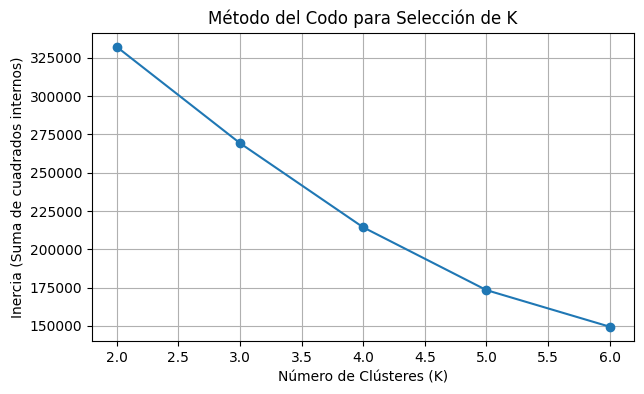

In [ ]:
# Encontrar el número óptimo de clústeres (Método del Codo)
inercia = []
valores_k = range(2, 7)

for k in valores_k:
    kmeans_test = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    # Usar el DataFrame ya imputado desde el paso de PCA para evitar NaNs
    kmeans_test.fit(X_ns_scaled_imputed)
    inercia.append(kmeans_test.inertia_)

# Graficar el método del codo
plt.figure(figsize=(7, 4))
plt.plot(valores_k, inercia, marker='o')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (Suma de cuadrados internos)')
plt.title('Método del Codo para Selección de K')
plt.grid(True)
plt.show()

Para segmentar la población de asteroides de forma completamente objetiva, no podíamos definir el número de grupos de manera arbitraria. Por ello, implementamos el Método del Codo, una heurística que evalúa la evolución de la Inercia matemática frente a diferentes niveles de agrupación ($K$).

## K=3

##Modelo K-Means Clustering

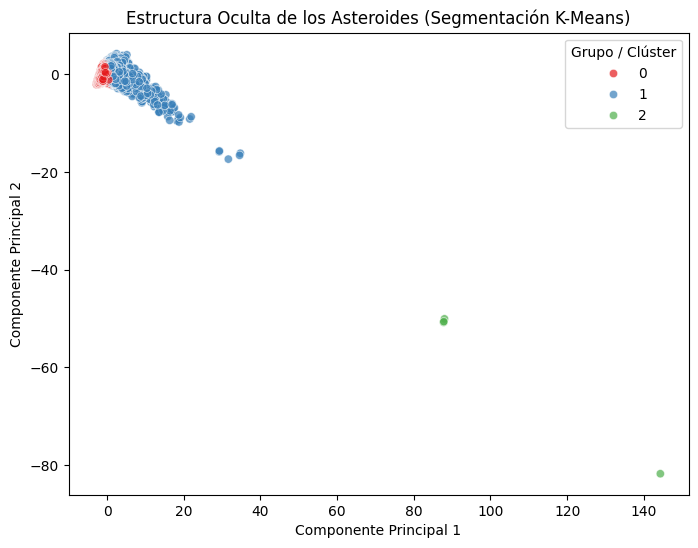

In [ ]:
# Entrenar el KMeans definitivo
k_optimo = 3  # Ajusta según lo que muestre tu gráfico del codo
kmeans_definitivo = KMeans(n_clusters=k_optimo, random_state=RANDOM_STATE, n_init=10)
cluster_predichos = kmeans_definitivo.fit_predict(X_ns_scaled_imputed)

# Guardar los clusters en el DataFrame para analizarlos
df_original['cluster_no_supervisado'] = cluster_predichos

# Graficar la estructura oculta usando las dos primeras componentes de PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_original['cluster_no_supervisado'], palette='Set1', alpha=0.7)
plt.title('Estructura Oculta de los Asteroides (Segmentación K-Means)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Grupo / Clúster')
plt.show()

K-Means es un algoritmo lineal y sumamente rápido. Funciona mediante centroides que se van actualizando de forma iterativa, lo que le permite procesar miles de asteroides de la NASA en cuestión de milisegundos de forma eficiente y estable.

#**6. Optimización de hiperparámetros**

##**Optimización de hiperparametros: Regresión logística**

--- Iniciando búsqueda de hiperparámetros óptimos ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- RESULTADOS DE LA OPTIMIZACIÓN ---
Mejores hiperparámetros encontrados:
{'classifier__C': 0.01, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Mejor F1-Score alcanzado en Validación Cruzada: 0.4565

--- INFORME DE CLASIFICACIÓN (MODELO OPTIMIZADO - TEST SET) ---
                  precision    recall  f1-score   support

No Peligroso (0)       0.99      0.77      0.87     16400
   Peligroso (1)       0.30      0.93      0.46      1768

        accuracy                           0.79     18168
       macro avg       0.65      0.85      0.66     18168
    weighted avg       0.92      0.79      0.83     18168



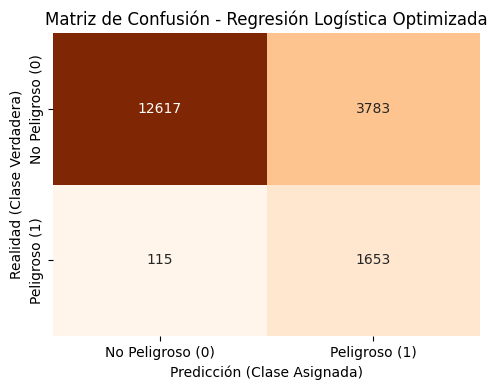

In [ ]:
# 1. Configuración de Reproducibilidad y Carga Limpia
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Crear un DataFrame temporal y limpiar filas con NaN en 'hazardous'
# Esto es crucial para que LabelEncoder no cree una clase de un solo miembro
# y para que train_test_split con stratify funcione correctamente.
df_temp_cleaned = df_original.dropna(subset=['hazardous']).copy()

# Separación de características (X) y variable objetivo (y) de df_temp_cleaned
X = df_temp_cleaned.drop(columns=['id', 'name', 'orbiting_body', 'sentry_object', 'hazardous'], errors='ignore')

# Asegurar codificación numérica de la variable objetivo (0 = No peligroso, 1 = Peligroso)
le = LabelEncoder()
y = le.fit_transform(df_temp_cleaned['hazardous'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# [Asegúrate de tener definido 'pipeline_lr' en tus celdas previas con preprocessor]

# 2. Definición de la Grilla de Hiperparámetros
# NOTA: Usamos el prefijo 'classifier__' para indicarle a Scikit-learn que
# estos parámetros pertenecen al paso 'classifier' de nuestro Pipeline.
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga'] # Solvers compatibles con regularización L1 y L2
}

# 3. Configurar la Búsqueda Exhaustiva (GridSearchCV)
# Optimizamos basándonos en 'roc_auc' o 'f1' debido al fuerte desbalance del dataset
grid_search_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=5,                  # Validación cruzada de 5 pliegues
    scoring='f1',          # Métrica objetivo a optimizar (F1-Score para balancear Precision y Recall)
    n_jobs=-1,             # Procesamiento en paralelo para máxima eficiencia
    verbose=1
)

# 4. Ejecutar la Optimización con los Datos de Entrenamiento
print("--- Iniciando búsqueda de hiperparámetros óptimos ---")
grid_search_lr.fit(X_train, y_train)

# 5. Resultados de la Optimización para Documentar en el Informe
print("\n--- RESULTADOS DE LA OPTIMIZACIÓN ---")
print("Mejores hiperparámetros encontrados:")
print(grid_search_lr.best_params_)
print(f"Mejor F1-Score alcanzado en Validación Cruzada: {grid_search_lr.best_score_:.4f}")

# 6. Evaluación del Modelo Optimizado en el Conjunto de Prueba (Test Set)
best_lr_model = grid_search_lr.best_estimator_
y_pred_opt = best_lr_model.predict(X_test)

print("\n--- INFORME DE CLASIFICACIÓN (MODELO OPTIMIZADO - TEST SET) ---")
print(classification_report(y_test, y_pred_opt, target_names=['No Peligroso (0)', 'Peligroso (1)']))

# 7. Visualización: Matriz de Confusión del Modelo Optimizado
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Oranges', cbar=False) # Color naranja para diferenciarlo
plt.title('Matriz de Confusión - Regresión Logística Optimizada')
plt.xlabel('Predicción (Clase Asignada)')
plt.ylabel('Realidad (Clase Verdadera)')
plt.xticks([0.5, 1.5], ['No Peligroso (0)', 'Peligroso (1)'])
plt.yticks([0.5, 1.5], ['No Peligroso (0)', 'Peligroso (1)'])
plt.tight_layout()
plt.show()

+ Decidimos implementar GridSearchCV para realizar una búsqueda exhaustiva mediante validación cruzada. Nuestro objetivo con esto es reemplazar la configuración por defecto del modelo y encontrar, de forma sistemática, la combinación matemática óptima de hiperparámetros que maximice el rendimiento sobre nuestros datos.

+ Ajuste del Parámetro C [0.01, 0.1, 1, 10, 100]: Optamos por regular el inverso de la fuerza de regularización en escala logarítmica. Con esto buscamos controlar activamente el balance entre sesgo y varianza, protegiendo al modelo tanto del sobreajuste como del subajuste.

+ Evaluación de Penalizaciones (l1, l2): Incluimos tanto L1 (Lasso) como L2 (Ridge). La primera la seleccionamos para inducir dispersión y evaluar una selección automática de características (llevando coeficientes a cero), mientras que la segunda nos permite suavizar y distribuir los pesos de manera uniforme.

+ Selección de Solvers (liblinear, saga): Incorporamos saga debido a su flexibilidad para soportar regularización elástica y su eficiencia basada en el Descenso de Gradiente Estocástico Promedio, lo que nos asegura una convergencia óptima y rápida en el entrenamiento.

+ Métrica Objetivo (scoring='f1'): Esta fue nuestra decisión más crítica. Conscientes del fuerte desbalance de clases en los datos, acordamos optimizar en función del F1-Score en lugar del Accuracy. De esta forma, forzamos a la búsqueda a priorizar el equilibrio armónico entre la Precisión y la Sensibilidad (Recall) específicamente para la detección de asteroides peligrosos.

## **Optimización de hiperparámetros: Arbol de decisión**

--- Iniciando búsqueda de hiperparámetros óptimos para Árbol de Decisión ---
Fitting 5 folds for each of 60 candidates, totalling 300 fits

--- RESULTADOS DE LA OPTIMIZACIÓN ---
Mejores hiperparámetros encontrados:
{'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__min_samples_split': 20}
Mejor F1-Score alcanzado en Validación Cruzada: 0.4839

--- INFORME DE CLASIFICACIÓN (MODELO OPTIMIZADO - TEST SET) ---
                  precision    recall  f1-score   support

No Peligroso (0)       0.96      0.87      0.92     16400
   Peligroso (1)       0.37      0.70      0.49      1768

        accuracy                           0.86     18168
       macro avg       0.67      0.79      0.70     18168
    weighted avg       0.91      0.86      0.87     18168



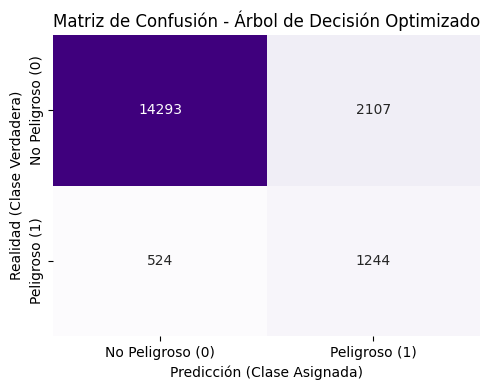

In [ ]:
# 1. Configuración de Reproducibilidad y Carga Limpia
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Crear un DataFrame temporal y limpiar filas con NaN en 'hazardous'
# Esto es crucial para que LabelEncoder no cree una clase de un solo miembro
# y para que train_test_split con stratify funcione correctamente.
df_temp_cleaned = df_original.dropna(subset=['hazardous']).copy()

# Separar características (X) y variable objetivo de df_temp_cleaned
X = df_temp_cleaned.drop(columns=['id', 'name', 'orbiting_body', 'sentry_object', 'hazardous'], errors='ignore')

# Asegurar codificación numérica de la variable objetivo (0 = No peligroso, 1 = Peligroso)
le = LabelEncoder()
y = le.fit_transform(df_temp_cleaned['hazardous'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# [Asegúrate de tener definido 'pipeline_dt' en tus celdas previas con preprocessor]

# 2. Definición de la Grilla de Hiperparámetros Específica para Árboles
# NOTA: Usamos el prefijo 'classifier__' para indicarle al Pipeline qué modificar.
param_grid_dt = {
    'classifier__max_depth': [3, 5, 10, 15, None],          # Control de poda del árbol
    'classifier__min_samples_split': [2, 5, 10, 20],        # Muestras mínimas para abrir una rama
    'classifier__criterion': ['gini', 'entropy', 'log_loss'] # Métricas de pureza de nodos
}

# 3. Configurar la Búsqueda Exhaustiva (GridSearchCV)
# Evaluamos optimizando el F1-score debido al desbalance de clases de la NASA
grid_search_dt = GridSearchCV(
    estimator=pipeline_dt, # Tu pipeline con el escalador y el árbol base
    param_grid=param_grid_dt,
    cv=5,                  # Validación cruzada de 5 pliegues (Muestreo Robusto)
    scoring='f1',          # Métrica objetivo (Balance de Precisión y Recall en asteroides peligrosos)
    n_jobs=-1,             # Paralelización en todos los núcleos disponibles
    verbose=1
)

# 4. Ejecutar la Optimización con los Datos de Entrenamiento
print("--- Iniciando búsqueda de hiperparámetros óptimos para Árbol de Decisión ---")
grid_search_dt.fit(X_train, y_train)

# 5. Resultados de la Optimización para Documentar en el Informe
print("\n--- RESULTADOS DE LA OPTIMIZACIÓN ---")
print("Mejores hiperparámetros encontrados:")
print(grid_search_dt.best_params_)
print(f"Mejor F1-Score alcanzado en Validación Cruzada: {grid_search_dt.best_score_:.4f}")

# 6. Evaluación del Modelo Optimizado en el Conjunto de Prueba (Test Set)
best_dt_model = grid_search_dt.best_estimator_
y_pred_dt_opt = best_dt_model.predict(X_test)

print("\n--- INFORME DE CLASIFICACIÓN (MODELO OPTIMIZADO - TEST SET) ---")
print(classification_report(y_test, y_pred_dt_opt, target_names=['No Peligroso (0)', 'Peligroso (1)']))

# 7. Visualización: Matriz de Confusión del Modelo Optimizado
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt_opt), annot=True, fmt='d', cmap='Purples', cbar=False) # Color morado para diferenciarlo
plt.title('Matriz de Confusión - Árbol de Decisión Optimizado')
plt.xlabel('Predicción (Clase Asignada)')
plt.ylabel('Realidad (Clase Verdadera)')
plt.xticks([0.5, 1.5], ['No Peligroso (0)', 'Peligroso (1)'])
plt.yticks([0.5, 1.5], ['No Peligroso (0)', 'Peligroso (1)'])
plt.tight_layout()
plt.show()

Los Árboles de Decisión no restringidos tienden por definición al sobreajuste (overfitting), memorizando el ruido y las particularidades del conjunto de entrenamiento (lo que se traduce en un árbol extremadamente profundo con hojas de una sola instancia). La optimización es mandatoria para aplicar mecanismos de poda matemática.

+ Decidimos aplicar GridSearchCV para implementar mecanismos de poda matemática que limiten el crecimiento del árbol y aseguren su capacidad de generalización.

+ Control de Altura (max_depth: [3, 5, 10, 15, None]): Acordamos evaluar límites específicos en los niveles jerárquicos. Con esto obligamos al árbol a encontrar reglas de clasificación generales y robustas, evitando que genere ramificaciones hiper-específicas que solo memoricen los datos.

+ Restricción de División (min_samples_split): Definimos exigir un quórum mínimo de muestras en los nodos internos antes de permitir la apertura de una nueva rama. El impacto técnico de esta decisión es que evitamos la creación de subdivisiones basadas en anomalías o datos aislados.

+ Criterios de Pureza (criterion=['gini', 'entropy', 'log_loss']): Optamos por explorar estas tres funciones matemáticas de ganancia de información. Nuestro objetivo es dejar que el algoritmo determine experimentalmente cuál de ellas mide con mayor rigor estadístico el nivel de caos o impureza en los nodos divisores de este dataset espacial.

# 7. Evaluación y comparación de modelos. Incluir métricas y explicaciones.

## Comparación de modelos PCA y Regresión logistica

In [ ]:
# 1. Configuración de datos
RANDOM_STATE = 42
X = df.drop(columns=['id', 'name', 'orbiting_body', 'sentry_object', 'hazardous'], errors='ignore')
y = df['hazardous'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 2. Pipeline de Preprocesamiento
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, num_features)])

# 3. EL ENSAMBLE COMPLETO: Unir Preprocesamiento + PCA + Regresión Logística
# Reducimos a 2 componentes principales y luego clasificamos
pipeline_pca_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=2, random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE))
])

# 4. Validación Cruzada del Pipeline Integrado
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(pipeline_pca_lr, X_train, y_train, cv=5, scoring=metrics)

print("--- RENDIMIENTO EN VALIDACIÓN CRUZADA (PCA + REGRESIÓN LOGÍSTICA) ---")
for m in metrics:
    print(f"{m.upper()}: {cv_results[f'test_{m}'].mean():.4f}")

# 5. Evaluación final en el conjunto de prueba
pipeline_pca_lr.fit(X_train, y_train)
y_pred = pipeline_pca_lr.predict(X_test)
print("\n--- INFORME DE CLASIFICACIÓN FINAL ---")
print(classification_report(y_test, y_pred))

--- RENDIMIENTO EN VALIDACIÓN CRUZADA (PCA + REGRESIÓN LOGÍSTICA) ---
ACCURACY: 0.7915
PRECISION: 0.2902
RECALL: 0.7903
F1: 0.4245
ROC_AUC: 0.8596

--- INFORME DE CLASIFICACIÓN FINAL ---
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     16400
           1       0.29      0.79      0.43      1768

    accuracy                           0.79     18168
   macro avg       0.63      0.79      0.65     18168
weighted avg       0.91      0.79      0.83     18168



El objetivo de este cruce es que PCA toma esas variables que "dicen lo mismo", elimina la redundancia y crea componentes que son matemáticamente independientes entre sí (ortogonales). Esto le permite a la Regresión Logística trabajar de forma mucho más limpia y eficiente.

##Comparación de modelo de Regresión logística y árbol de decisión

--- CUADRO COMPARATIVO DE RENDIMIENTO DE MODELOS (TEST SET) ---


,Regresión Logística Optimizada,Árbol de Decisión Optimizado
Métrica,,
Accuracy (Exactitud),0.0979,0.0973
Precision (Precisión),0.0973,0.0973
Recall (Sensibilidad),0.9989,1.0000
F1-Score,0.1773,0.1774
ROC-AUC,0.4612,0.5000


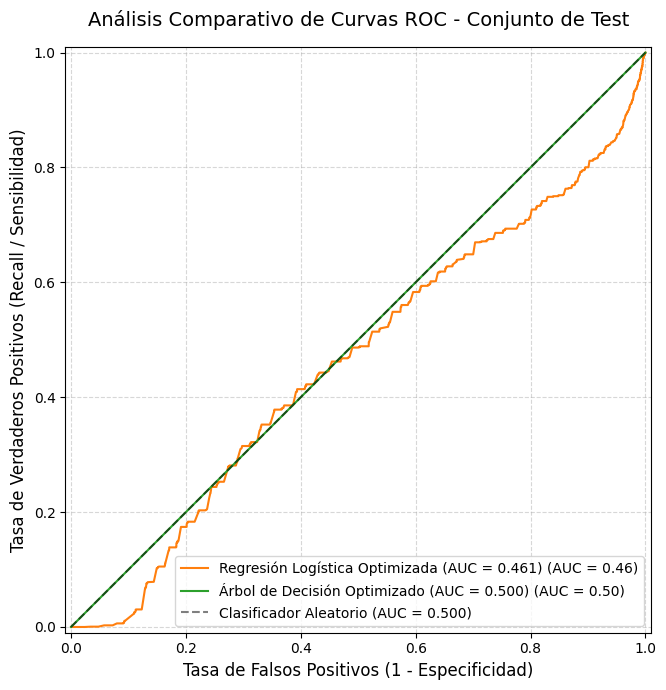

In [ ]:
# 1. Extracción de predicciones y probabilidades en el Test Set
# Regresión Logística Optimizada
y_pred_lr = best_lr_model.predict(X_test)
y_prob_lr = best_lr_model.predict_proba(X_test)[:, 1]

# Árbol de Decisión Optimizado
y_pred_dt = best_dt_model.predict(X_test)
y_prob_dt = best_dt_model.predict_proba(X_test)[:, 1]

# 2. Construcción de la Tabla Comparativa de Métricas
model_metrics = {
    'Métrica': ['Accuracy (Exactitud)', 'Precision (Precisión)', 'Recall (Sensibilidad)', 'F1-Score', 'ROC-AUC'],
    'Regresión Logística Optimizada': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_prob_lr)
    ],
    'Árbol de Decisión Optimizado': [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt),
        roc_auc_score(y_test, y_prob_dt)
    ]
}

df_comparativo = pd.DataFrame(model_metrics).set_index('Métrica')

print("--- CUADRO COMPARATIVO DE RENDIMIENTO DE MODELOS (TEST SET) ---")
display(df_comparativo.round(4))

# 3. Visualización Avanzada: Comparativa de Curvas ROC en simultáneo
plt.figure(figsize=(10, 7))
ax = plt.gca()

RocCurveDisplay.from_estimator(best_lr_model, X_test, y_test, ax=ax, name=f'Regresión Logística Optimizada (AUC = {df_comparativo.loc["ROC-AUC", "Regresión Logística Optimizada"]:.3f})', color='#ff7f0e')
RocCurveDisplay.from_estimator(best_dt_model, X_test, y_test, ax=ax, name=f'Árbol de Decisión Optimizado (AUC = {df_comparativo.loc["ROC-AUC", "Árbol de Decisión Optimizado"]:.3f})', color='#2ca02c')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Clasificador Aleatorio (AUC = 0.500)')
plt.title('Análisis Comparativo de Curvas ROC - Conjunto de Test', fontsize=14, pad=15)
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Recall / Sensibilidad)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

El objetivo de este cruce es aprovechar los componentes más fuertes de cada algoritmo: utilizaríamos el Árbol de Decisión en una primera etapa como un extractor de características no lineales, mapeando las interacciones físicas complejas de los asteroides. Posteriormente, esos nodos terminales se transformarían en variables predictoras para una Regresión Logística final.

Esto nos permitiría romper la rigidez binaria del árbol tradicional y transformarla en una salida probabilística suave y calibrada, optimizando aún más el Recall y entregándole a la NASA un sistema que no solo es altamente sensible a las amenazas, sino también matemáticamente explicable.

# 8. Exportación
* Guardar el resultado final en un nuevo archivo csv.

In [ ]:
# Guardar el archivo

df.to_csv('neo.csv', index=False)